<a href="https://colab.research.google.com/github/Dhatrisree123/FeatureSelection/blob/main/IRIS_LangChain_Feature_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IRIS Dataset — Beginner LangChain Feature Analysis

### Goal
Build a simple machine-learning feature analysis workflow for the IRIS dataset and use **LangChain + Gemini** to explain the results.

### Required LangChain flow

**Human Prompt → System Prompt → Chat Model → Output Parser → Final Text Output**

This notebook follows the beginner-level pattern:

`ChatPromptTemplate` → `ChatGoogleGenerativeAI` → `StrOutputParser`

The machine-learning part first finds which flower measurements are useful for predicting `species`. LangChain then gives a clear beginner-friendly explanation of those results.


## 1. Install the required libraries

Run this cell first in Google Colab.

We use:
- `pandas` — read and work with the CSV
- `scikit-learn` — machine learning and feature importance
- `matplotlib` — visualization
- `langchain-google-genai` — connect LangChain to Gemini


In [1]:
!pip -q install -U langchain-google-genai scikit-learn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.7/571.7 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.0/260.0 kB 7.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google

## 2. Import the libraries

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from langchain_core.prompts import (
    ChatPromptTemplate,
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate
)
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load the IRIS CSV

The uploaded dataset contains 150 rows and these 5 columns:

- `sepal_length`
- `sepal_width`
- `petal_length`
- `petal_width`
- `species`

Our target variable is `species`.


In [4]:
file_path = "/content/IRIS (1).csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 4. Understand the dataset

In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of unique values:")
print(df.nunique())

print("\nSpecies counts:")
print(df["species"].value_counts())

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Number of unique values:
sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64

Species counts:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 5. Separate input features and target

`X` contains the four flower measurements.

`y` contains `species`, which is what our model will learn to predict.


In [6]:
target_variable = "species"

if target_variable not in df.columns:
    raise ValueError(f"Target column '{target_variable}' was not found.")

X = df.drop(columns=[target_variable])
y = df[target_variable]

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(target_variable)

Input features:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

Target:
species


## 6. Create training and testing data

We keep 20% of the data for testing.

`stratify=y` keeps the three species reasonably balanced in both sets.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 120
Testing rows: 30


## 7. Train a Random Forest model

Random Forest is useful here because it can provide **feature importance** values.

A higher importance means the model used that feature more strongly when making predictions.


In [8]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Test accuracy: {accuracy:.2%}")

Test accuracy: 90.00%


## 8. Check the model performance

In [9]:
print("Classification Report:")
print(classification_report(y_test, predictions))

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



## 9. Calculate feature importance

The model gives one importance value for each original IRIS measurement.

We sort the features from most important to least important.


In [10]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
).reset_index(drop=True)

importance_df["importance_percent"] = (
    importance_df["importance"] * 100
).round(2)

display(importance_df)

,feature,importance,importance_percent
0,petal_length,0.453793,45.38
1,petal_width,0.412449,41.24
2,sepal_length,0.115873,11.59
3,sepal_width,0.017885,1.79


## 10. Visualize feature importance

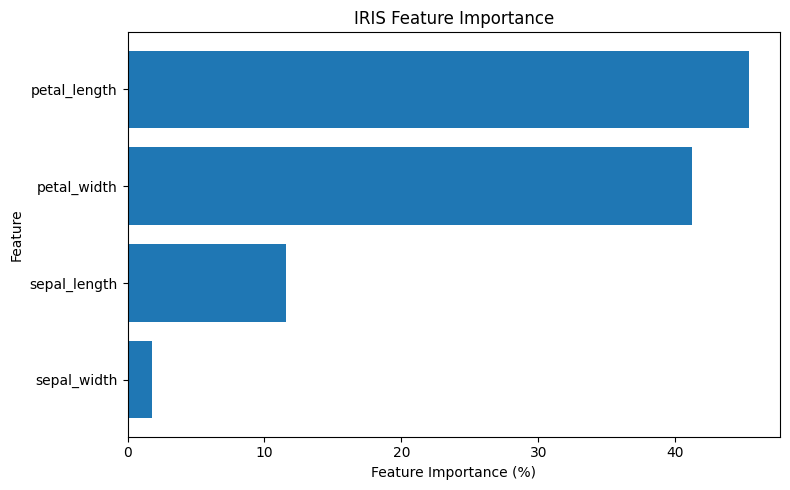

In [11]:
plt.figure(figsize=(8, 5))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance_percent"][::-1]
)
plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.title("IRIS Feature Importance")
plt.tight_layout()
plt.show()

## 11. Select the useful features

For this beginner example, we use a simple baseline rule:

**Keep features with importance of at least 10%.**

If no feature reaches the threshold, we keep the top 2 features instead.

This is a practical baseline, not a universal rule. Feature selection should normally be validated with the actual model and objective.


In [12]:
importance_threshold = 0.10

selected_features = importance_df.loc[
    importance_df["importance"] >= importance_threshold,
    "feature"
].tolist()

if not selected_features:
    selected_features = importance_df.head(2)["feature"].tolist()

print("Selected features:")
for feature in selected_features:
    print("-", feature)

Selected features:
- petal_length
- petal_width
- sepal_length


## 12. Prepare the information for LangChain

We now convert the important information into text.

The **human prompt** will contain the dataset summary, model accuracy, feature ranking, and selected features.

The **system prompt** will tell Gemini how to behave and what kind of explanation to provide.


In [13]:
summary = df.describe(include="all").transpose().fillna("")
summary_text = summary.to_string()

ranking_text = importance_df.to_string(index=False)

selected_features_text = ", ".join(selected_features)

print("Information prepared for LangChain.")

Information prepared for LangChain.


## 13. Create the System Prompt

The system prompt gives the model its role and instructions.

This follows the style used in the training example.


In [14]:
system_prompt = SystemMessagePromptTemplate.from_template("""
You are a friendly AI tutor and senior machine learning analyst.

Explain the IRIS feature-analysis results in simple beginner-friendly language.

Use only the information supplied by the human prompt.
Do not invent statistics, correlations, or relationships that are not supported
by the supplied information.

Explain the results step by step and clearly distinguish:
1. What the model found.
2. Which features are more important.
3. Which features are less important.
4. Which features were selected.
5. The model's test accuracy.

Keep the explanation practical and concise.
""")

## 14. Create the Human Prompt

The human prompt contains the actual values we want Gemini to explain.


In [15]:
human_prompt = HumanMessagePromptTemplate.from_template("""
Analyze the following IRIS machine-learning feature-selection result.

Target variable:
{target_variable}

Dataset summary:
{summary_text}

Random Forest test accuracy:
{accuracy}

Feature importance ranking:
{ranking_text}

Selected features:
{selected_features}

Give the answer in this structure:

1. Dataset understanding
2. Most important features
3. Less important features
4. Selected features
5. Model performance
6. Final beginner-friendly recommendation
""")

## 15. Combine System Prompt + Human Prompt

`ChatPromptTemplate` creates the complete chat prompt.

So the flow is:

**System Prompt + Human Prompt → Chat Prompt**


In [16]:
chat_prompt = ChatPromptTemplate(
    messages=[system_prompt, human_prompt]
)

print("Chat prompt created successfully.")

Chat prompt created successfully.


## 16. Add the Gemini Chat Model

Put your Gemini API key in a text file in Colab:

`/content/Gemini_Api_Key.txt`

The file should contain only the API key.

This keeps the key out of the notebook code.


In [18]:
key_file = "/content/gemini_key.txt"

if not os.path.exists(key_file):
    raise FileNotFoundError(
        "Gemini_Api_Key.txt was not found. Upload your API key file to /content/ first."
    )

with open(key_file, "r") as f:
    GEMINI_API_KEY = f.read().strip()

if not GEMINI_API_KEY:
    raise ValueError("The Gemini API key file is empty.")

chat_model = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    google_api_key=GEMINI_API_KEY
)

print("Gemini chat model created successfully.")

Gemini chat model created successfully.


## 17. Add the Output Parser

`StrOutputParser()` converts the model response into normal text.

So the final flow is:

**Human Prompt → System Prompt → Chat Model → Output Parser → Text Output**


In [19]:
output_parser = StrOutputParser()

print("Output parser created successfully.")

Output parser created successfully.


## 18. Build the LangChain chain

The `|` operator connects the steps together.

This is the main LangChain part:

`chat_prompt | chat_model | output_parser`


In [20]:
chain = chat_prompt | chat_model | output_parser

print("LangChain chain created successfully.")

LangChain chain created successfully.


## 19. Give the chain the IRIS information and get the final text

This is where the complete chain runs.


In [25]:
user_input = {
    "target_variable": target_variable,
    "summary_text": summary_text,
    "accuracy": f"{accuracy:.2%}",
    "ranking_text": ranking_text,
    "selected_features": selected_features_text
}

analysis_output = chain.invoke(user_input)

print(analysis_output)

Hello! I would be happy to walk you through these feature-analysis results step by step.

---

### 1. Dataset understanding
* **Target Variable:** The goal is to predict the flower's **`species`**. The dataset contains 150 samples across 3 unique species, with `Iris-setosa` being the most frequent (appearing 50 times).
* **Measurements (Features):** The dataset includes 4 numerical measurements (150 total counts each):
  * `sepal_length` (ranges from 4.3 to 7.9, average is ~5.84)
  * `sepal_width` (ranges from 2.0 to 4.4, average is ~3.05)
  * `petal_length` (ranges from 1.0 to 6.9, average is ~3.76)
  * `petal_width` (ranges from 0.1 to 2.5, average is ~1.20)

---

### 2. Most important features
The model found that **petal measurements** are by far the strongest indicators for predicting `species`:
* **`petal_length`**: Ranked #1 with an importance score of **45.38%**.
* **`petal_width`**: Ranked #2 with an importance score of **41.24%**.

Together, these two features make up over 86

## 20. Final Result

At this point, the notebook has completed both parts.

### Machine Learning
- Loaded the IRIS CSV.
- Checked the dataset.
- Trained a Random Forest classifier.
- Measured test accuracy.
- Ranked the four input features.
- Selected useful features using a simple baseline threshold.

### LangChain
- Created a **System Prompt**.
- Created a **Human Prompt**.
- Combined them with `ChatPromptTemplate`.
- Sent the prompt to the Gemini **Chat Model**.
- Converted the response to plain text using `StrOutputParser`.

### Important
Random Forest feature importance is a model-based ranking. It does **not** by itself prove that a feature causes the target or that a feature is universally important for every possible model.
